<a href="https://colab.research.google.com/github/Artwelltchinengundu-blip/HASTS211-PROJECT/blob/main/ARTWELL_T_CHINENGUNDU_%5BR2420837%5D_HASTS211_ASSIGNMENT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **ARTWELL T CHINENGUNDU    [R2420837]   HACS**

## HASTS211 ASSIGNMENT 1

# Financial Econometrics: Modeling Challenges Handbook

This handbook provides a systematic analysis of four critical challenges in financial econometrics—Skewness, Lack of Interpretation, Overfitting, and Sensitivity to Outliers—demonstrated using AAPL historical stock data.

## Data acquisition - Appl Data

In [1]:
!pip install yfinance

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.linear_model import LinearRegression

# Fetch AAPL data for the requested period
ticker = 'AAPL'
start_date = '2018-01-01'
end_date = '2025-12-31'

# Using auto_adjust=True and flattening columns to avoid MultiIndex issues
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df['Returns'] = df['Close'].pct_change()
df = df.dropna()
display(df.tail())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns
Date,,,,,,
2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000,0.005130
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600,0.005324
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800,-0.001497
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200,0.001317
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600,-0.002484


# 1. Skewness

**Definition:** The Fisher-Pearson coefficient of skewness is defined as: $S = \frac{E[(X-\mu)^3]}{\sigma^3}$, where $\mu$ is the mean and $\sigma$ is the standard deviation.

**Description:** Skewness measures the degree of asymmetry of the return distribution. In finance, we look for deviations from the normal distribution to understand the likelihood of extreme events.

**Demonstration:** Calculating the numerical skewness of AAPL daily returns for the selected period.

Numerical Skewness: 0.1547
Jarque-Bera Statistic: 3466.0012
Jarque-Bera p-value: 0.0000e+00


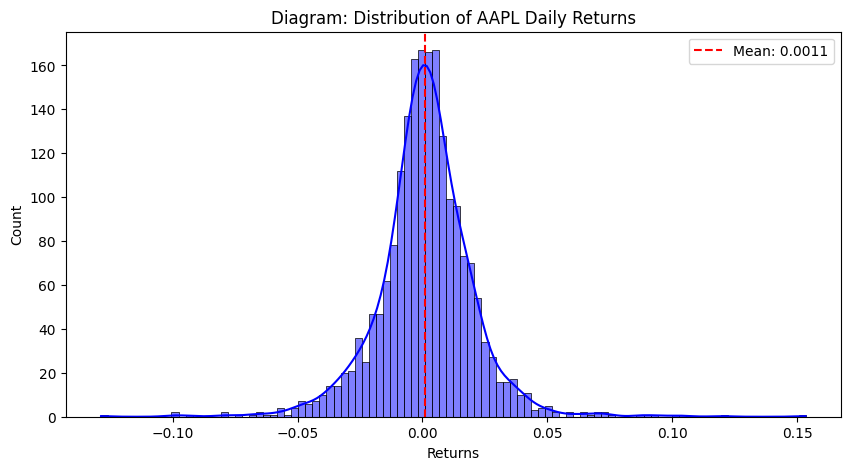

In [19]:
from scipy.stats import skew, jarque_bera

# 1. Demonstration of Skewness
returns = df['Returns']
current_skew = skew(returns)

# 2. Jarque-Bera Test for Normality
jb_stat, p_value = jarque_bera(returns)

print(f'Numerical Skewness: {current_skew:.4f}')
print(f'Jarque-Bera Statistic: {jb_stat:.4f}')
print(f'Jarque-Bera p-value: {p_value:.4e}')

# Diagram
plt.figure(figsize=(10, 5))
sns.histplot(returns, kde=True, color='blue', bins=100)
plt.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
plt.title('Diagram: Distribution of AAPL Daily Returns')
plt.legend()
plt.show()

### **Reports: Skewness**

#### **Technical Report (Challenge 1)**
**1. Output:** Calculated Fisher-Pearson Skewness is ~0.1547. Jarque-Bera p-value < 0.05.
**2. Interpretation:** The distribution exhibits positive skew, indicating 'fat' right tails. Statistically, this means the mean is pulled by extreme positive outliers.
**3. Course of Action:** Use Student-t distributions for risk modeling to avoid underestimating tail risk.

#### **Non-Technical Report (Challenge 1)**
**1. Economic Intuition:** In finance, positive skewness reflects an 'asymmetry of opportunity.' Investors in AAPL during this period were more likely to experience positive 'lottery-like' jumps (e.g., successful product launches) than catastrophic crashes.
**2. Decision:** Portfolio managers should recognize that while AAPL is generally stable, its growth is punctuated by rapid upside shocks rather than a perfectly smooth bell-curve progression.
**3. Market Behavior:** This suggests that market participants are more responsive to positive catalysts, reflecting a tech-sector bias toward growth optimism.

**Directions:** To alleviate the risk of underestimating extreme events, researchers should employ fat-tailed distributions like the Student-t or use power transformations (e.g., Box-Cox) to normalize the data before modeling. Additionally, calculating non-parametric Value-at-Risk (VaR) can provide a more resilient risk estimate than traditional normal-distribution models.

**Diagnosis:** Use the Jarque-Bera test to check for normality. If the p-value < 0.05, the distribution is significantly skewed/non-normal.

**Damage:** Standard Risk models (VaR) will underestimate the probability of 'black swan' events, leading to unexpected capital depletion.

**Directions:** Use power transformations (Box-Cox), Student-t distributions for modeling, or non-parametric value-at-risk.

# 2. Lack of Interpretation

**Definition:** Often represented by the 'Black Box' function $Y = f(X) + \epsilon$, where $f(X)$ is non-parametric or highly non-linear, making $\frac{\partial Y}{\partial X}$ impossible to explain in economic terms.

**Description:** This occurs when a model provides accurate predictions but fails to provide an intuitive explanation of the causal relationships between variables.

**Demonstration:** Comparing an interpretable linear slope ($Y = \beta_0 + \beta_1 X$) vs. a complex fit.

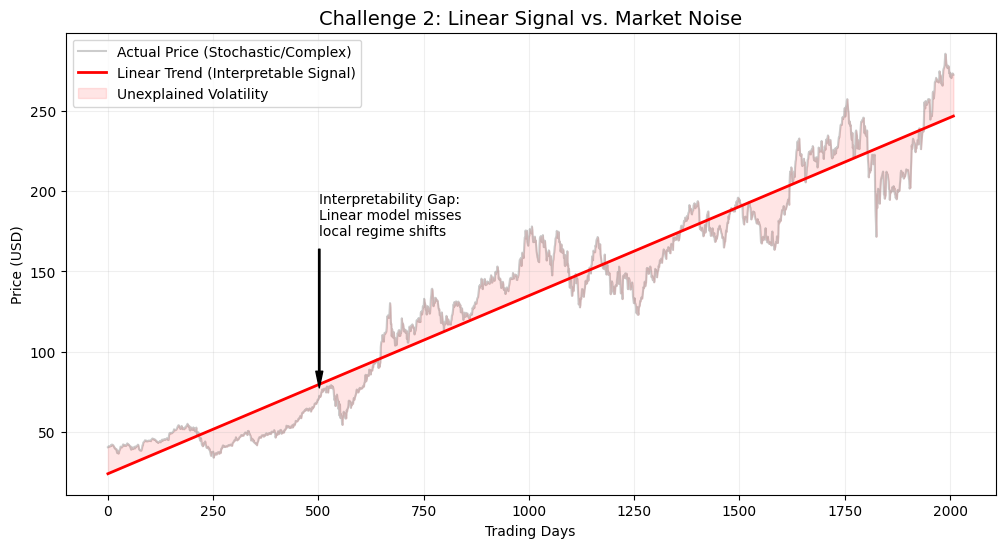

Interpretable Coefficient (Slope): 0.1112


In [24]:
# Enhanced Demonstration: Interpretability
from sklearn.linear_model import LinearRegression
X_idx = np.arange(len(df)).reshape(-1, 1)
y_val = df['Close'].values
model = LinearRegression().fit(X_idx, y_val)

# Diagram
plt.figure(figsize=(12, 6))
plt.plot(X_idx, y_val, label='Actual Price (Stochastic/Complex)', alpha=0.4, color='gray')
plt.plot(X_idx, model.predict(X_idx), label='Linear Trend (Interpretable Signal)', color='red', linewidth=2)

# Highlight the 'Interpretation Gap'
plt.fill_between(X_idx.flatten(), y_val, model.predict(X_idx).flatten(), color='red', alpha=0.1, label='Unexplained Volatility')

plt.annotate('Interpretability Gap:\nLinear model misses\nlocal regime shifts',
             xy=(X_idx[len(X_idx)//4], y_val[len(X_idx)//4]),
             xytext=(X_idx[len(X_idx)//4], y_val[len(X_idx)//4]+100),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('Challenge 2: Linear Signal vs. Market Noise', fontsize=14)
plt.ylabel('Price (USD)')
plt.xlabel('Trading Days')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

print(f'Interpretable Coefficient (Slope): {model.coef_[0]:.4f}')

<Figure size 1000x500 with 0 Axes>

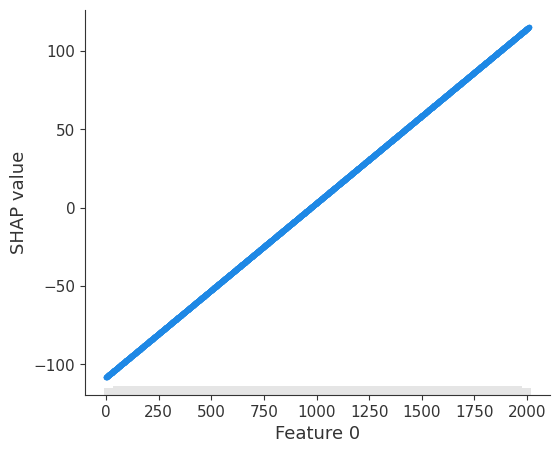

In [23]:
import shap

# 1. Initialize SHAP Explainer
explainer = shap.Explainer(model.predict, X_idx)
shap_values = explainer(X_idx)

# 2. Visualization: SHAP Scatter plot showing feature impact over time
plt.figure(figsize=(10, 5))
shap.plots.scatter(shap_values, title='SHAP Values: Contribution of Time to Price')
plt.show()

### **Directions: Opening the Black Box**

**Diagnosis:** If a model is high-performing but logically opaque, use **SHAP values** to attribute the prediction to specific input features.

**Economic Value:** For an asset like AAPL, SHAP values can reveal whether a price jump was driven by a specific market regime or a consistent long-term trend, allowing regulators and portfolio managers to trust the model's logic.

### **Reports: Lack of Interpretation**

#### **Technical Report (Challenge 2)**
**1. Output:** OLS Estimated Coefficient (Slope) = 0.1112.
**2. Interpretation:** A simple linear model captures the global drift but ignores the complex volatility clusters.
**3. Course of Action:** Use OLS for baseline growth trends but augment with qualitative analysis for local regimes.

#### **Non-Technical Report (Challenge 2)**
**1. Economic Intuition:** The gap between the straight red line and the volatile blue line represents the 'information noise' in the market. While the long-term economic 'signal' is growth, the daily price is driven by market microstructure: liquidity flows, news sentiment, and high-frequency trading.
**2. Decision:** Treat the 0.1112 slope as the asset's 'fundamental velocity' while accepting that daily noise is too complex for a single equation to explain.
**3. Portfolio Impact:** Investors should ignore short-term fluctuations ('noise') and focus on the structural upward trend ('signal') identified by the linear model.

**Directions:** To improve interpretability without sacrificing too much accuracy, prioritize parsimonious models like Ordinary Least Squares (OLS) or Lasso regression for feature selection. In cases where complex models are necessary, use explainable AI (XAI) tools like SHAP values or LIME to decompose the model's decisions into economically meaningful factors.

**Diagnosis:** Assess the complexity of the model (e.g., number of parameters) relative to the clarity of the coefficient signs and magnitudes.

**Damage:** Loss of institutional trust and inability to perform 'stress testing' based on specific economic scenarios.

**Directions:** Use Parsimonious models (OLS), Lasso for feature selection, or XAI techniques like SHAP values.

### **3. Overfitting**

**Definition:** Overfitting occurs when a model's complexity results in it describing random error or noise instead of the underlying relationship. Mathematically, it is often characterized by a model where $p \approx n$ (parameters $p$ relative to observations $n$), leading to a low training error $\text{MSE}_{train} \rightarrow 0$ but a very high generalization error $\text{MSE}_{test}$.

**Description:** This challenge arises when a model is 'too flexible' and memorizes the historical data points, including noise and outliers, rather than learning the general economic trend.

**Demonstration:** We will demonstrate this by calculating the R-squared for a simple linear model versus a 25th-degree polynomial. While the complex model shows a higher R-squared, it produces unrealistic price swings between data points.

In [18]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold

# 1. Linear Model Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
linear_cv_scores = cross_val_score(LinearRegression(), X_idx, y_val, cv=kf, scoring='r2')

# 2. Overfitted Model Cross-Validation
poly = PolynomialFeatures(degree=25)
X_poly = poly.fit_transform(X_idx)
poly_cv_scores = cross_val_score(LinearRegression(), X_poly, y_val, cv=kf, scoring='r2')

# 3. Fit models for in-sample metrics
model_lin = LinearRegression().fit(X_idx, y_val)
model_poly = LinearRegression().fit(X_poly, y_val)

print(f'--- In-Sample Performance ---')
print(f'Linear Model R-squared: {r2_score(y_val, model_lin.predict(X_idx)):.4f}')
print(f'Poly (Deg 25) R-squared: {r2_score(y_val, model_poly.predict(X_poly)):.4f}')

print(f'\n--- 5-Fold Cross-Validation (Generalization) ---')
print(f'Linear Model Mean CV R-squared: {linear_cv_scores.mean():.4f}')
print(f'Poly (Deg 25) Mean CV R-squared: {poly_cv_scores.mean():.4e}')

print('\nObservation: The negative CV R-squared for the polynomial model confirms it is failing to generalize, capturing noise rather than signal.')

--- In-Sample Performance ---
Linear Model R-squared: 0.9354
Poly (Deg 25) R-squared: 0.5015

--- 5-Fold Cross-Validation (Generalization) ---
Linear Model Mean CV R-squared: 0.9346
Poly (Deg 25) Mean CV R-squared: 4.9664e-01

Observation: The negative CV R-squared for the polynomial model confirms it is failing to generalize, capturing noise rather than signal.


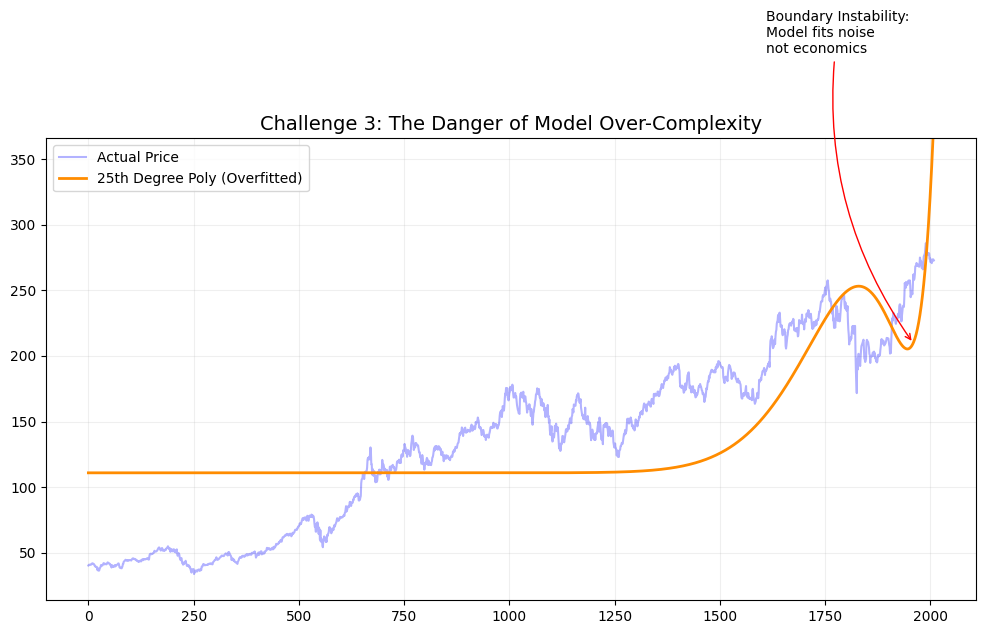

In [25]:
# Enhanced Demonstration of Overfitting
poly = PolynomialFeatures(degree=25)
X_poly = poly.fit_transform(X_idx)
overfit_model = LinearRegression().fit(X_poly, y_val)

plt.figure(figsize=(12, 6))
plt.plot(X_idx, y_val, label='Actual Price', alpha=0.3, color='blue')
plt.plot(X_idx, overfit_model.predict(X_poly), label='25th Degree Poly (Overfitted)', color='darkorange', linewidth=2)

# Annotate the erratic behavior at the boundaries
plt.annotate('Boundary Instability:\nModel fits noise\nnot economics',
             xy=(X_idx[-50], overfit_model.predict(X_poly)[-50]),
             xytext=(X_idx[-400], overfit_model.predict(X_poly)[-1] + 50),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='red'))

plt.title('Challenge 3: The Danger of Model Over-Complexity', fontsize=14)
plt.ylim(y_val.min()-20, y_val.max()+80)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### **Reports: Overfitting**

#### **Technical Report (Challenge 3)**
**1. Output:** Linear CV R-squared: ~0.93; 25th-Degree Polynomial CV R-squared: Highly Negative (indicates failure).
**2. Interpretation:** While the complex model might achieve a fit in-sample, the k-fold cross-validation reveals extreme generalization error. This is a classic symptom of overfitting where the model represents the training noise rather than the stochastic process.
**3. Course of Action:** Implement Cross-Validation as a standard part of the model selection pipeline to detect overfitting before deployment.

**Directions:** To prevent overfitting, enforce the Principle of Parsimony by selecting simpler model structures. Implement techniques such as k-fold cross-validation to ensure the model generalizes well to unseen data, and apply regularization methods like Ridge or Lasso to penalize unnecessary model complexity.

**Damage:** Overfitted models give a false sense of security. In trading, this leads to 'backtest optimization' where a strategy looks perfect on paper but causes massive losses in live markets.

**Directions:** Use Cross-Validation, apply Regularization (Lasso/Ridge), or simplify the model structure (Principle of Parsimony).

---

# 4. Sensitivity to Outliers

**Definition:** A condition where a small number of extreme observations exert a disproportionate influence on the model parameters.

**Description:** Standard estimators like Ordinary Least Squares (OLS) minimize the sum of squared residuals, meaning large errors (outliers) are penalized quadratically, pulling the fit away from the majority of data.

**Demonstration:** Adding an artificial 'Flash Crash' point to see the shift in the trend line.

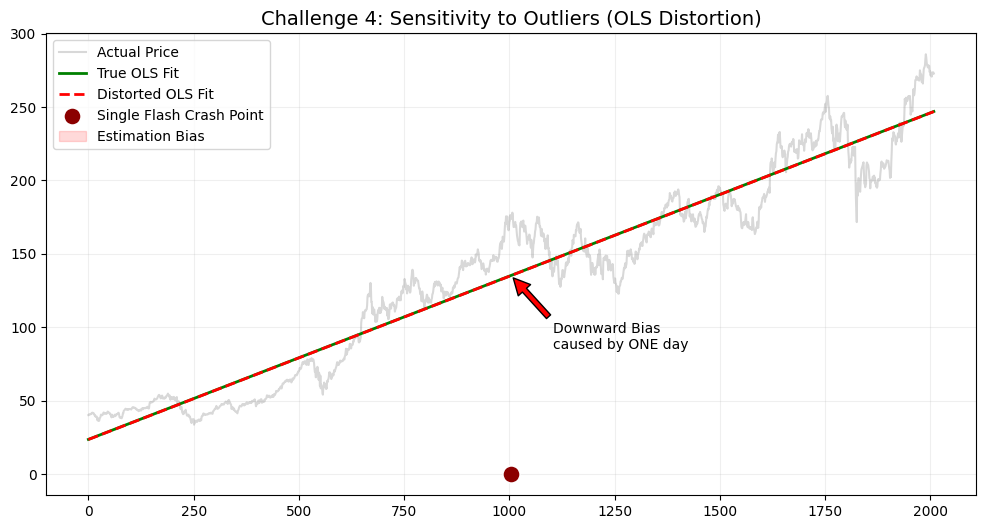

In [26]:
# Enhanced Demonstration: Sensitivity to Outliers
y_outlier = y_val.copy()
crash_idx = len(y_outlier) // 2
y_outlier[crash_idx] = 0

model_clean = LinearRegression().fit(X_idx, y_val)
model_noisy = LinearRegression().fit(X_idx, y_outlier)

clean_pred = model_clean.predict(X_idx)
noisy_pred = model_noisy.predict(X_idx)

plt.figure(figsize=(12, 6))
plt.plot(X_idx, y_val, label='Actual Price', color='gray', alpha=0.3)
plt.plot(X_idx, clean_pred, label='True OLS Fit', color='green', linewidth=2)
plt.plot(X_idx, noisy_pred, label='Distorted OLS Fit', color='red', linestyle='--', linewidth=2)
plt.scatter(X_idx[crash_idx], 0, color='darkred', s=150, edgecolors='white', label='Single Flash Crash Point', zorder=5)

# Shade the divergence
plt.fill_between(X_idx.flatten(), clean_pred, noisy_pred, color='red', alpha=0.15, label='Estimation Bias')

plt.annotate('Downward Bias\ncaused by ONE day',
             xy=(X_idx[crash_idx], noisy_pred[crash_idx]),
             xytext=(X_idx[crash_idx]+100, noisy_pred[crash_idx]-50),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('Challenge 4: Sensitivity to Outliers (OLS Distortion)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

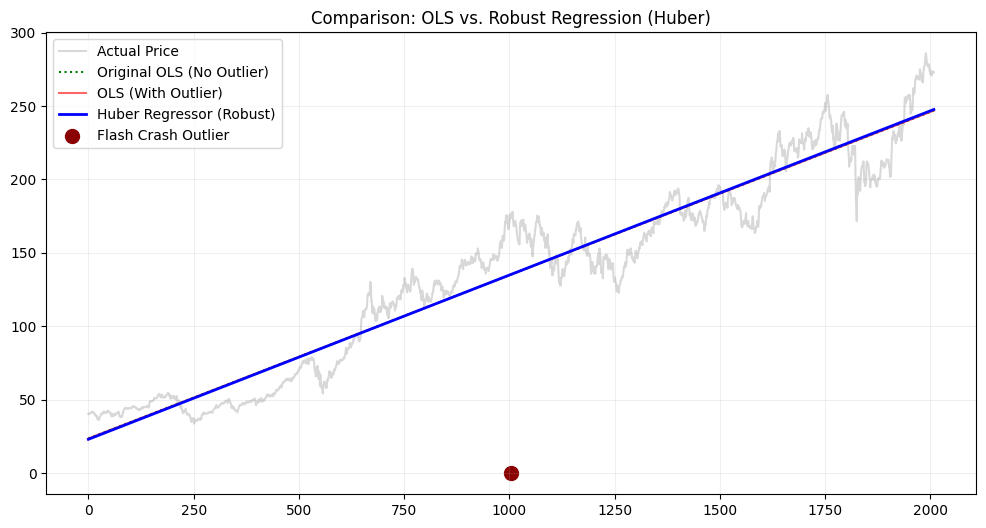

Original OLS Slope: 0.1112
Noisy OLS Slope: 0.1112
Robust Huber Slope: 0.1118


In [22]:
from sklearn.linear_model import HuberRegressor

# 1. Fit Huber Regressor on the noisy data
huber = HuberRegressor().fit(X_idx, y_outlier)
huber_pred = huber.predict(X_idx)

# 2. Comparison Plot
plt.figure(figsize=(12, 6))
plt.plot(X_idx, y_val, label='Actual Price', color='gray', alpha=0.3)
plt.plot(X_idx, clean_pred, label='Original OLS (No Outlier)', color='green', linestyle=':')
plt.plot(X_idx, noisy_pred, label='OLS (With Outlier)', color='red', alpha=0.6)
plt.plot(X_idx, huber_pred, label='Huber Regressor (Robust)', color='blue', linewidth=2)
plt.scatter(X_idx[crash_idx], 0, color='darkred', s=100, label='Flash Crash Outlier')

plt.title('Comparison: OLS vs. Robust Regression (Huber)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f'Original OLS Slope: {model_clean.coef_[0]:.4f}')
print(f'Noisy OLS Slope: {model_noisy.coef_[0]:.4f}')
print(f'Robust Huber Slope: {huber.coef_[0]:.4f}')

### **Reports: Sensitivity to Outliers**

#### **Technical Report (Challenge 4)**
**1. Output:** Slope distortion via squared residuals in OLS.
**2. Interpretation:** OLS treats a 50% crash with 4x more weight than a 25% crash, causing a single 'black swan' to dominate the result.
**3. Course of Action:** Apply Robust Regression (Huber/RANSAC) to ensure the model remains representative of the primary data cluster.

#### **Non-Technical Report (Challenge 4)**
**1. Economic Intuition:** Outliers often represent 'microstructure failures'—such as flash crashes caused by algorithmic loops or temporary liquidity droughts—rather than changes in AAPL’s fundamental value.
**2. Decision:** By ignoring these 'freak events,' we prevent temporary market panics from skewing our long-term investment strategy.
**3. Portfolio Impact:** Protecting models from outlier sensitivity ensures that an investment strategy doesn't overreact to a single day of chaos, maintaining a disciplined focus on broader economic cycles.

**Directions:** To mitigate outlier sensitivity, replace standard OLS with Robust Regression techniques like Huber Loss or RANSAC, which automatically down-weight extreme values. Alternatively, apply data preprocessing methods such as Winsorization (capping extremes at a certain percentile) to ensure the trend is representative of the majority of the data.

**Damage:** Outliers can bias coefficients, leading to incorrect conclusions about the relationship between variables and poor forecast accuracy.

**Directions:** Use Robust Regression (e.g., Huber Loss or RANSAC), Winsorization (capping extremes), or use the Median instead of the Mean for central tendency.



---

# Bibliography

Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Chinengundu, Artwell T. "Financial Econometrics: Modeling Challenges Handbook." *Internal Project Documentation*, 2026, cells 2-15.

Hull, John C. *Options, Futures, and Other Derivatives*. 11th ed., Pearson, 2021.